# Understanding the Roman WFI Distortion Reference File

## Kernel Information and Read-Only Status

To run this notebook, please select "Roman Research Nexus {VERSION}" kernel at the top right of your window. For example "Roman Research Nexus 2026.2".

This notebook is read-only. You can run cells and make edits, but you must save changes to a different location. We recommend saving the notebook within your home directory, or to a new folder within your home (e.g. <span style="font-variant:small-caps;">file > save notebook as > my-nbs/nb.ipynb</span>). Note that a directory must exist before you attempt to add a notebook to it.
    

## Introduction
The purpose of this notebook is to understand the content and purpose of the **Distortion** (`DISTORTION`) reference file.

This file contains the astrometric distortion model used by the `romancal.assign_wcs` step to convert between detector coordinates and world (sky) coordinates. It is critical for accurate astrometry and mosaicking.

More details about this and other reference files can be found in the [Reference File Information](https://roman-pipeline.readthedocs.io/en/stable/roman/references_general/index.html).

### Local Run Settings

If you want to run the notebook in your local machine, refer to the information in [local installation](../../markdown/local-run.md) instructions before proceeding with the notebook. The instructions provide important information about setting up your environment and installing dependencies.

## Imports
Libraries used:
- *astropy* for image normalization
- *copy* for making copies of Python objects
- *crds* for access to calibration reference files
- *matplotlib* and *mpl_toolkits* for plotting images
- *numpy* for array manipulation
- *roman_datamodels* for opening Roman WFI ASDF files
- *os* for operating system functions

In [1]:
import os
from astropy.visualization import simple_norm
import copy

import matplotlib.pyplot as plt
from matplotlib import colors, colormaps as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import roman_datamodels as rdm

### The Calibration Reference Data System (CRDS)

The reference files, developed and validated by STScI’s Science Operations Center, are continually updated as new WFI data become available. For more information about how CRDS works and how it assigns the most appropriate reference file for each calibration step, refer to the notebook [Understanding CRDS and How to Select Calibration Reference files](crds_reference_files.ipynb). 

**IMPORTANT NOTE:** Reference files are a work in progress and will be updated several times before Roman launch. If you notice irregularities or missing information, please understand that they may be a known issue. If you have questions, please contact the [Roman Help Desk](https://romanhelp.stsci.edu).

To make use of `CRDS` functionality, we need to import the whole package. 

In [2]:
import crds

Now let's dive into this reference file type.

### Distortion Reference File

The DISTORTION reference file is used in the `assign_wcs` step to model geometric distortions of the WFI optics. It is typically an Astropy `CompoundModel` containing polynomial or SIP (Simple Imaging Polynomial) transformations.

For more details, see the [romancal assign_wcs documentation](https://roman-pipeline.readthedocs.io/en/latest/roman/assign_wcs/index.html) and
[Rdox documentation](https://roman-docs.stsci.edu/data-handbook/roman-wfi-data-pipelines/exposure-level-pipeline#ExposureLevelPipeline-assign_wcs) for the WCS assignment.


Before proceeding, let's check the environmental variables set for CRDS

In [3]:
print(f"CRDS server location: {os.environ.get('CRDS_SERVER_URL')}")
print(f"CRDS context file: {os.environ.get('CRDS_CONTEXT')}")

CRDS server location: https://roman-crds.stsci.edu
CRDS context file: roman-edit


If we want to change the context, we can do it in the next cell. In this case, we choose context `roman_0055.pmap`.

In [4]:
os.environ['CRDS_CONTEXT']='roman_0055.pmap'

### Retrieving Reference Files

As you run the exposure pipeline, the most up-to-date reference files will be automatically selected for each step. However, if you would like to use a specific reference file, retrieve it using the `CRDS` Python API and feed it to the Exposure Level Pipeline, see the notebook [Understanding CRDS and How to Select Calibration Reference files](crds_reference_files.ipynb) for more details. 

For the REFPIX files, the required keywords are typically:
- `ROMAN.META.INSTRUMENT.NAME`
- `ROMAN.META.INSTRUMENT.DETECTOR`
- `ROMAN.META.INSTRUMENT.OPTICAL_ELEMENT`
- `ROMAN.META.EXPOSURE.TYPE`
- `ROMAN.META.EXPOSURE.START_TIME`

These keywords may be combined into a single dictionary that is later fed to the  `crds.getrecommendations` function. This function returns a dictionary of file names that match the criteria that you supply. 

In [5]:
meta = {
    'ROMAN.META.INSTRUMENT.NAME': 'WFI',
    'ROMAN.META.INSTRUMENT.DETECTOR': 'WFI01',
    'ROMAN.META.INSTRUMENT.OPTICAL_ELEMENT': 'F158',
    'ROMAN.META.EXPOSURE.TYPE': 'WFI_IMAGE',
    'ROMAN.META.EXPOSURE.START_TIME': '2026-01-01 00:00:00'
}

ref_files = crds.getreferences(meta, reftypes=['distortion'], observatory='roman')
ref_files

{'distortion': '/home/runner/crds_cache/references/roman/wfi/roman_wfi_distortion_0014.asdf'}

### Examining Reference Files

Reference files use `roman_datamodels` just like WFI science data products. Let's take a closer look at the DISTORTION reference file:


In [6]:
dist = rdm.open(ref_files['distortion'])
dist.info(max_rows=200)

root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 3.5.0
├─history (AsdfDictNode)
│ ├─entries (AsdfListNode)
│ │ └─0 (HistoryEntry)
│ │   ├─description (str): This file was made using pysiaf version 0.22.0 and the Roman Science Instrument A (truncated)
│ │   └─time (datetime): 2024-06-14 05:04:03+00:00
│ └─extensions (AsdfListNode)
│   ├─0 (ExtensionMetadata)
│   │ ├─extension_class (str): asdf.extension._manifest.ManifestExtension
│   │ ├─extension_uri (str): asdf://asdf-format.org/core/extensions/core-1.5.0
│   │ ├─manifest_software (Software)
│   │ │ ├─name (str): asdf_standard
│   │ │ └─version (str): 1.1.1
│   │ └─software (Software)
│   │   ├─name (str): asdf-astropy
│   │   └─version (str): 0.6.1
│   ├─1 (ExtensionMetadata)
│   │ ├─extension_class (str): asdf.extension._manifest.ManifestExtension
│   │ ├─extension_uri (str): asdf://asdf-format.org/transfo

The Distortion reference file contains metadata and an Astropy model - the Distortion Transform Model representing the transform from detector to the telescope V2, V3 system. Let's inspect the model:

In [7]:
model = dist.coordinate_distortion_transform
print("=== Full Model Representation ===")
print(model)

print("\n=== Model Parameters ===")
print(model.parameters)

print("\n=== Model Components ===")
for i, submodel in enumerate(model):
    print(f"Component {i}: {submodel}")

=== Full Model Representation ===
Model: CompoundModel
Inputs: ('x0', 'x1')
Outputs: ('y0', 'y1')
Model set size: 1
Expression: [0] & [1] | [2] & [3] | [4] | [5] & [6] | [7] | [8] & [9] | [10] & [11]
Components: 
    [0]: <Shift(offset=1.)>

    [1]: <Shift(offset=1.)>

    [2]: <Shift(offset=-2044.5)>

    [3]: <Shift(offset=-2044.5)>

    [4]: <Mapping((0, 1, 0, 1))>

    [5]: <Polynomial2D(5, c0_0=0., c1_0=0.11034133, c2_0=-0.00000003, c3_0=-0., c4_0=0., c5_0=-0., c0_1=0.00034168, c0_2=-0.00000001, c0_3=-0., c0_4=-0., c0_5=0., c1_1=0.00000014, c1_2=-0., c1_3=0., c1_4=0., c2_1=0., c2_2=-0., c2_3=-0., c3_1=0., c3_2=-0., c4_1=-0.)>

    [6]: <Polynomial2D(5, c0_0=0., c1_0=0.00031436, c2_0=0.00000007, c3_0=0., c4_0=0., c5_0=-0., c0_1=0.10828278, c0_2=0.00000021, c0_3=-0., c0_4=0., c0_5=0., c1_1=-0.00000002, c1_2=-0., c1_3=-0., c1_4=0., c2_1=-0., c2_2=-0., c2_3=0., c3_1=-0., c3_2=-0., c4_1=-0.)>

    [7]: <Mapping((0, 1, 0, 1))>

    [8]: <Polynomial2D(1, c0_0=0., c1_0=-0.5, c0_1=-0.8660

### Basic Statistics
We can also get some basic statistics. First let's evealuate the model on a representative grid,

In [8]:
# Evaluate the model on a grid to create distortion maps
# (downsampled for speed)
ny, nx = 4088, 4088
step = 10  # adjust for resolution vs speed
y, x = np.mgrid[0:ny:step, 0:nx:step]

# Apply the model 
x_corr, y_corr = model(x, y)

dx = x_corr - x
dy = y_corr - y
dist_mag = np.hypot(dx, dy)

print(f"Distortion magnitude range: {dist_mag.min():.4f} — {dist_mag.max():.4f} pixels")

Distortion magnitude range: 1097.2329 — 6044.2851 pixels


Now get some statistics on the distortion magnitude

In [9]:
print("Distortion statistics:")
print(f"  Mean offset X: {dx.mean():.4f} pixels")
print(f"  Mean offset Y: {dy.mean():.4f} pixels")
print(f"  Max distortion: {dist_mag.max():.4f} pixels")

Distortion statistics:
  Mean offset X: -726.8376 pixels
  Mean offset Y: -3080.3934 pixels
  Max distortion: 6044.2851 pixels


### Visualizing the Distortion
Now, let's plot the distortion magnitude map (X and Y offsets) grid

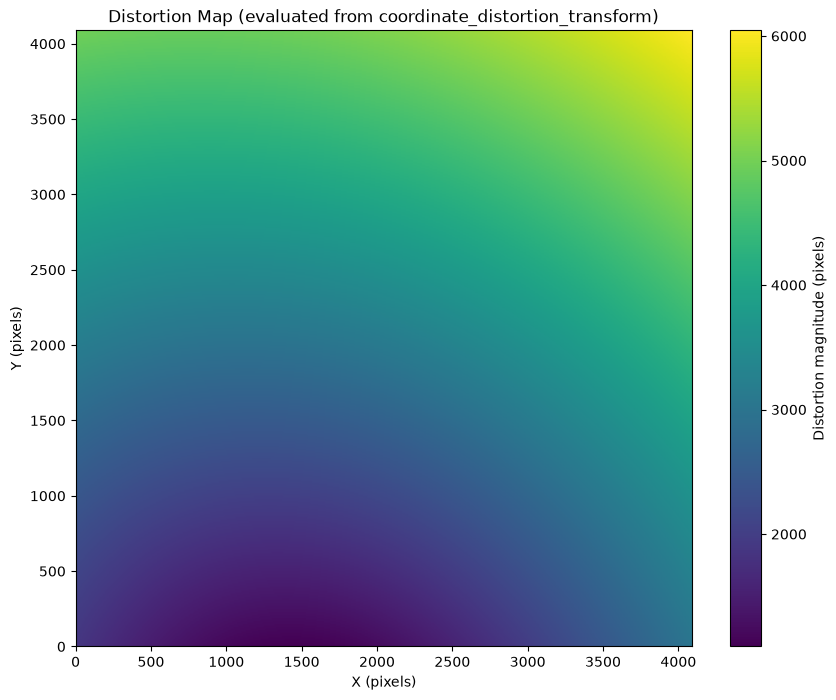

In [10]:
# Plot distortion magnitude map
plt.figure(figsize=(10, 8))
plt.imshow(dist_mag, origin='lower', cmap='viridis', extent=[0, nx, 0, ny])
plt.colorbar(label='Distortion magnitude (pixels)')
plt.title('Distortion Map (evaluated from coordinate_distortion_transform)')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.show()

Finally, let's get a view as a vector field

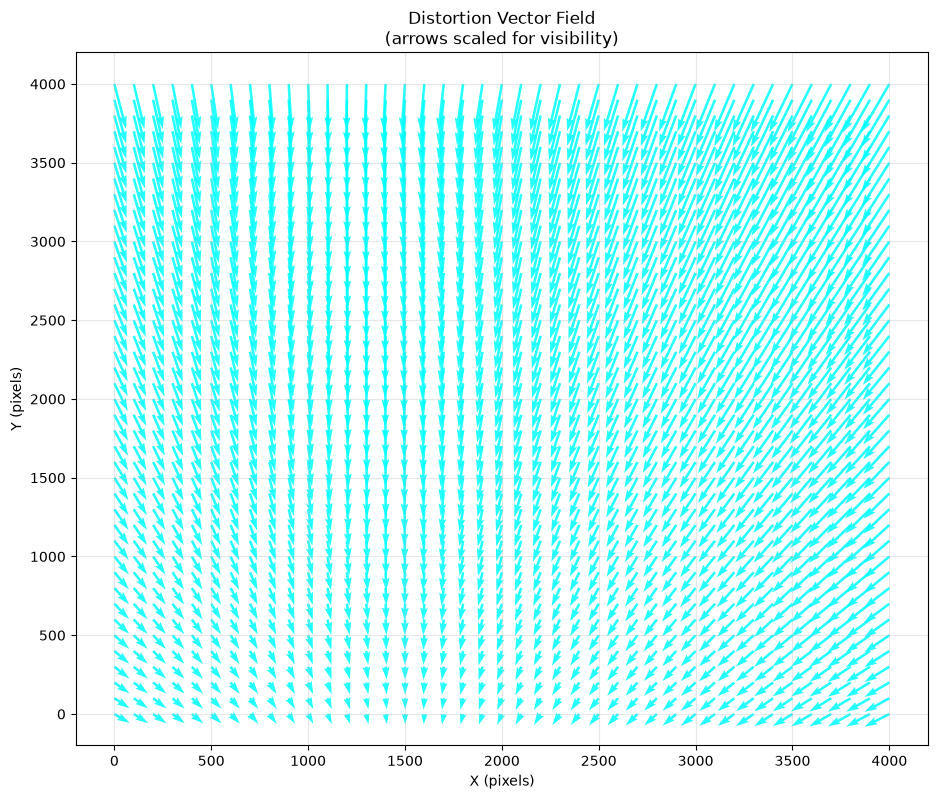

In [11]:
# Vector field with strong scaling + normalization
plt.figure(figsize=(11, 9))

step_vec = 10  # adjust density

# Normalize vector length for visibility
scale_factor = 90000   # tune this number (higher = shorter arrows)

plt.quiver(x[::step_vec, ::step_vec], 
           y[::step_vec, ::step_vec],
           dx[::step_vec, ::step_vec], 
           dy[::step_vec, ::step_vec],
           scale=scale_factor,  
           color='cyan', 
           alpha=0.85, 
           width=0.003,
           headwidth=3)

plt.title('Distortion Vector Field\n(arrows scaled for visibility)')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.grid(True, alpha=0.3)
plt.show()

## About this Notebook
**Author:** R. Diaz

**Updated On:** 2026-07-06

<table width="100%" style="border:none; border-collapse:collapse;">

  <tr style="border:none;">
    <td style="border:none; width:180px; white-space:nowrap;">
       <a href="#top" style="text-decoration:none; color:#0066cc;"> Top of page</a>
    </td>
    <td style="border:none; text-align:center;">
        <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/roman_logo.png" alt="roman_logo" width="50px">
    </td>
    <td style="border:none; text-align:right;">
       <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/stsci_logo2.png" width="90">
    </td>
  </tr>
</table>